# 02 — Embedding Models

Embeddings are the backbone of semantic search in a RAG pipeline.
The **embedding model** you choose determines how well your system understands the meaning of text and/or images — and directly affects retrieval quality.

In this notebook you will:

1. Load **real crawled data** (text + images) from notebook 01
2. Compare **four embedding models** served via an OpenAI-compatible API:
   - **miniLM** — fast, lightweight text embeddings
   - **octen-embedding-8b** — high-dimensional text embeddings
   - **dinov3-vit-large** — image-only embeddings
   - **qwen3-vl-embedding-8b** — multimodal (text + image) embeddings
3. Measure **dimensions**, **speed**, and **similarity behaviour**
4. Demonstrate **cross-modal retrieval** (text → image, image → text)
5. Evaluate retrieval quality with **MRR** and **nDCG@5**

---

## 1 · Setup

> **Prerequisites:**
> - Qdrant running at `localhost:6333` (`docker compose up qdrant -d`)
> - A `.env` file in the `notebooks/` directory with `OPENAI_API_KEY` and `OPENAI_API_BASE`
> - Crawled data from notebook 01 in `raw_data/data_crawled/`

In [1]:
from qdrant_client import QdrantClient, models
import openai
import os
import base64
import io
import numpy as np
import time
import hashlib
import uuid
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from PIL import Image
import requests as http_requests

load_dotenv()

# ── OpenAI-compatible client (proxy for all 4 models) ──
API_KEY = os.getenv("OPENAI_API_KEY")
if not API_KEY:
    raise ValueError("OPENAI_API_KEY is missing. Set it in notebooks/.env")

BASE_URL = os.getenv("OPENAI_API_BASE", "https://api.aisc.hpi.de/")

client = openai.OpenAI(api_key=API_KEY, base_url=BASE_URL)
print(f"OpenAI client ready  →  {BASE_URL}")

OpenAI client ready  →  https://api.aisc.hpi.de/


In [2]:
# ── Embedding cache (RECREATE toggle) ──
# Set RECREATE=True to ignore cached embeddings and force re-computation.
RECREATE = False
CACHE_DIR = Path("embedding_cache")
CACHE_DIR.mkdir(exist_ok=True)


def cached_embed(key: str, fn) -> np.ndarray:
    """Return cached numpy array under CACHE_DIR/<key>.npy or compute via fn() and persist.

    Args:
        key: stable filename stub (e.g. "corpus_octen_4096").
        fn:  zero-arg callable returning the array (or list of arrays — stacked automatically).
    """
    path = CACHE_DIR / f"{key}.npy"
    if path.exists() and not RECREATE:
        print(f"  [cache hit ] {path.name}")
        return np.load(path)
    print(f"  [cache miss] {path.name} — computing ...")
    result = fn()
    if isinstance(result, list):
        arr = np.vstack([np.asarray(x).reshape(1, -1) if np.asarray(x).ndim == 1 else np.asarray(x) for x in result])
    else:
        arr = np.asarray(result)
    np.save(path, arr)
    return arr


print(f"Embedding cache ready  →  {CACHE_DIR}/   (RECREATE={RECREATE})")


Embedding cache ready  →  embedding_cache/   (RECREATE=False)


In [3]:
# Connect to local Qdrant instance
qdrant = QdrantClient(host="localhost", port=6333)
print("Qdrant collections:", [c.name for c in qdrant.get_collections().collections])

Qdrant collections: ['nb_chars_4000', 'rag_titanic', 'nb_octen_mrl_256', 'nb_chars_4000_overlap', 'nb_octen_mrl_512', 'nb_octen_mrl_4096', 'nb_chars_1000', 'nb_octen_mrl_2048', 'rag_multiple_tools', 'nb_words_100', 'nb_octen_mrl_128', 'tep_pdfs', 'nb_paragraph', 'workshop_rag', 'nb_octen_mrl_1024', 'aisc_demo', 'rag_basic', 'rag_agentic']


---
## 2 · Load Crawled Data

We load **text** (Markdown files) and **images** produced by notebook 01's crawler.
For the text-embedding comparison we also define a set of labelled evaluation queries
so we can measure retrieval quality.

In [4]:
# ── 2a: Load crawled text ──
DATA_DIR = Path("raw_data/data_crawled")

DOCUMENTS = {}
for fp in sorted(DATA_DIR.glob("*.md")):
    text = fp.read_text(encoding="utf-8").strip()
    if text:
        DOCUMENTS[fp.stem] = text

print(f"Loaded {len(DOCUMENTS)} text documents from {DATA_DIR}/")
total_chars = sum(len(t) for t in DOCUMENTS.values())
lengths = [len(t) for t in DOCUMENTS.values()]
print(f"  Total chars: {total_chars:,}")
print(f"  Avg / min / max length: {np.mean(lengths):.0f} / {min(lengths)} / {max(lengths)}")
print()
for name, text in DOCUMENTS.items():
    print(f"  {name}: {len(text):>6,} chars, ~{len(text.split()):>4} words")

Loaded 20 text documents from raw_data/data_crawled/
  Total chars: 114,392
  Avg / min / max length: 5720 / 90 / 15037

  agb:  9,658 chars, ~1156 words
  barrierefreiheit:  5,319 chars, ~ 554 words
  connect-messe:  7,685 chars, ~ 893 words
  datenschutz:  9,802 chars, ~1131 words
  diabetes-verstehen-eine-woche-cgm-selbstexperiment-am-hpi:  6,160 chars, ~ 736 words
  forschung:  4,227 chars, ~ 378 words
  hausordnung:  9,218 chars, ~1184 words
  homepage:  6,634 chars, ~ 702 words
  hpi-verabschiedet-feierlich-141-absolventinnen:  7,297 chars, ~ 967 words
  impact:  2,714 chars, ~ 309 words
  impressum:  2,670 chars, ~ 282 words
  institut:  2,850 chars, ~ 302 words
  ki-servicezentrum:  9,355 chars, ~ 963 words
  kontakt:  2,122 chars, ~ 216 words
  news-events:  3,176 chars, ~ 338 words
  potsdamer-konferenz-fuer-nationale-cybersicherheit: 15,037 chars, ~1807 words
  studium:  4,193 chars, ~ 484 words
  suche:     90 chars, ~  11 words
  transfer:  2,935 chars, ~ 327 words
  wider

### 2b · Load / generate image data

We try to load images crawled in notebook 01 (`raw_data/data_crawled/images/`).
As a supplement we also **generate synthetic charts** — bar, line, scatter, pie,
heatmap, box-plot — so we have controlled image data regardless of what the
crawler collected.

Loaded 22 downloaded images from raw_data/images/
Generated 8 synthetic charts
Total images: 30


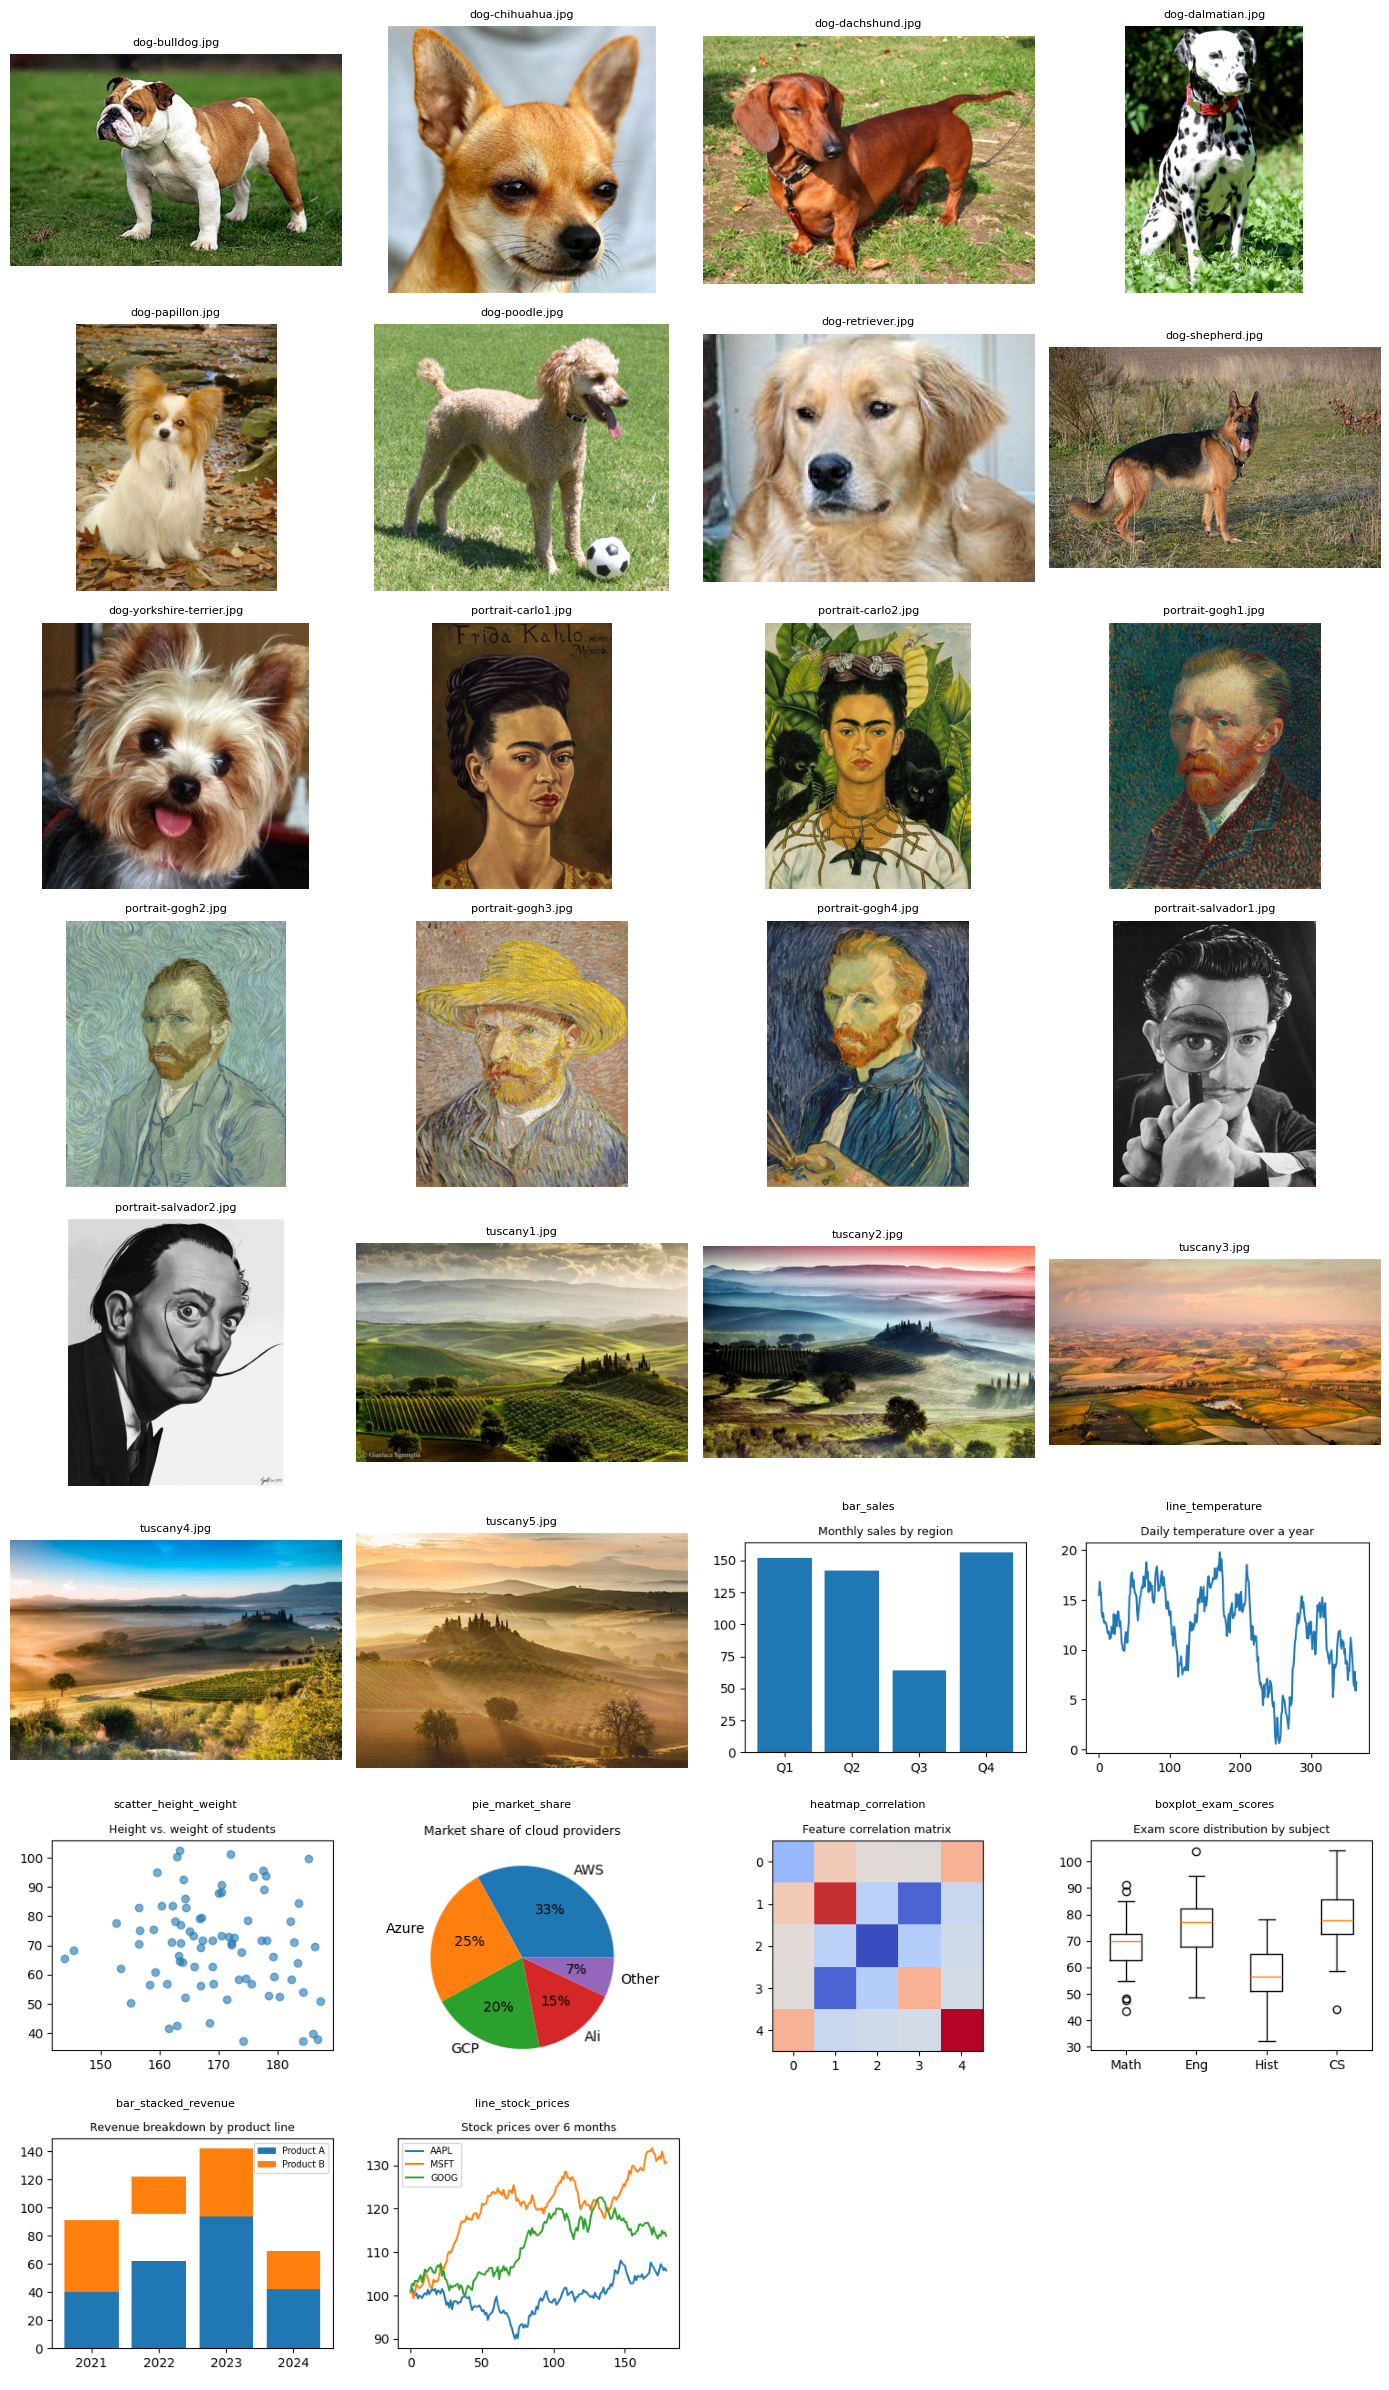

In [5]:
# ── 2b: Load fixed image set + generate synthetic charts ──

def img_to_base64(path: str | Path) -> str:
    """Read an image file and return its base64-encoded string."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def fig_to_base64(fig) -> str:
    """Convert a matplotlib figure to a PNG base64 string."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


IMAGES: list[dict] = []   # each: {"name": str, "base64": str, "source": str}

# 1. Fixed downloaded image set (dogs, portraits, landscapes)
IMG_DIR = Path("raw_data/images")
if not IMG_DIR.exists():
    raise FileNotFoundError(
        f"Image directory {IMG_DIR} not found. "
        "Expected pre-downloaded images committed to the repository."
    )

for fp in sorted(IMG_DIR.iterdir()):
    if fp.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".gif"}:
        IMAGES.append({"name": fp.name, "base64": img_to_base64(fp), "source": "downloaded"})
print(f"Loaded {sum(1 for i in IMAGES if i['source']=='downloaded')} downloaded images from {IMG_DIR}/")

# 2. Synthetic charts (always generated for a controlled demo alongside real photos)
np.random.seed(42)
CHART_SPECS = [
    ("bar_sales",        "Monthly sales by region"),
    ("line_temperature", "Daily temperature over a year"),
    ("scatter_height_weight", "Height vs. weight of students"),
    ("pie_market_share", "Market share of cloud providers"),
    ("heatmap_correlation", "Feature correlation matrix"),
    ("boxplot_exam_scores", "Exam score distribution by subject"),
    ("bar_stacked_revenue", "Revenue breakdown by product line"),
    ("line_stock_prices", "Stock prices over 6 months"),
]

for chart_name, title in CHART_SPECS:
    fig, ax = plt.subplots(figsize=(4, 3))
    if "bar_sales" in chart_name:
        ax.bar(["Q1", "Q2", "Q3", "Q4"], np.random.randint(50, 200, 4))
    elif "line_temp" in chart_name:
        ax.plot(range(365), np.cumsum(np.random.randn(365)) + 15)
    elif "scatter" in chart_name:
        ax.scatter(np.random.normal(170, 10, 80), np.random.normal(70, 15, 80), alpha=0.6)
    elif "pie" in chart_name:
        ax.pie([33, 25, 20, 15, 7], labels=["AWS", "Azure", "GCP", "Ali", "Other"], autopct="%1.0f%%")
    elif "heatmap" in chart_name:
        data = np.random.rand(5, 5)
        data = (data + data.T) / 2
        ax.imshow(data, cmap="coolwarm")
    elif "boxplot" in chart_name:
        ax.boxplot([np.random.normal(loc, 10, 40) for loc in [65, 72, 58, 80]], tick_labels=["Math", "Eng", "Hist", "CS"])
    elif "stacked" in chart_name:
        x = ["2021", "2022", "2023", "2024"]
        ax.bar(x, np.random.randint(40, 100, 4), label="Product A")
        ax.bar(x, np.random.randint(20, 60, 4), bottom=np.random.randint(40, 100, 4), label="Product B")
        ax.legend(fontsize=7)
    elif "stock" in chart_name:
        for s in ["AAPL", "MSFT", "GOOG"]:
            ax.plot(range(180), np.cumsum(np.random.randn(180)) + 100, label=s)
        ax.legend(fontsize=7)
    ax.set_title(title, fontsize=9)
    IMAGES.append({"name": chart_name, "base64": fig_to_base64(fig), "source": "synthetic"})

print(f"Generated {sum(1 for i in IMAGES if i['source']=='synthetic')} synthetic charts")
print(f"Total images: {len(IMAGES)}")

# Preview grid
n = len(IMAGES)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3 * rows))
axes = np.array(axes).flatten()
for i, img_dict in enumerate(IMAGES):
    img = Image.open(io.BytesIO(base64.b64decode(img_dict["base64"])))
    axes[i].imshow(img)
    axes[i].set_title(img_dict["name"], fontsize=8)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


---
## 3 · Embedding Model Overview & Helper Functions

| Model | API endpoint | Modality | Notes |
|-------|-------------|----------|-------|
| `minilm-embedding` | `embeddings.create` | Text | Fast, lightweight |
| `octen-embedding-8b` | `embeddings.create` | Text | High-dimensional, high-quality |
| `dinov3-vit-large` | `embeddings.create` | Image | Vision-only (DINOv2 family) |
| `qwen3-vl-embedding-8b` | `embeddings.create` | Text + Image | True multimodal |

All models are accessible through the same OpenAI-compatible proxy.

In [6]:
# ── Model wrapper functions ──

MAX_RETRIES = 4
RETRY_BACKOFF = 2  # seconds; doubles each retry → 2, 4, 8, 16
IMG_MAX_PIXELS = 768  # resize images so longest side ≤ this value

def _retry(fn, *args, label="api", **kwargs):
    """Call `fn(*args, **kwargs)` with exponential-backoff retries on transient errors."""
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as exc:
            msg = str(exc).lower()
            transient = (
                "500" in msg
                or "connection" in msg          # aborted / reset / error
                or "internalservererror" in msg
                or "timeout" in msg or "timed out" in msg
                or "remote disconnected" in msg
            )
            if transient and attempt < MAX_RETRIES:
                wait = RETRY_BACKOFF * (2 ** (attempt - 1))
                print(f"  ⟳ {label}: attempt {attempt}/{MAX_RETRIES} failed ({exc.__class__.__name__}), retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise


def _truncate(text: str, max_chars: int = 500) -> str:
    """Truncate text to approximately `max_chars` characters (~200 tokens).
    miniLM has a hard 256-token limit; this keeps inputs safely below it.
    Truncates at the last space before the limit to avoid mid-word cuts.
    """
    if len(text) <= max_chars:
        return text
    truncated = text[:max_chars]
    # Cut at last space to avoid mid-word truncation
    last_space = truncated.rfind(" ")
    if last_space > max_chars // 2:
        truncated = truncated[:last_space]
    return truncated


def _resize_image_b64(b64: str, max_side: int = IMG_MAX_PIXELS) -> str:
    """Resize a base64 image so its longest side ≤ max_side pixels.
    Returns re-encoded base64. Skips resizing if already small enough.
    This keeps token counts within the 32K context window of qwen3-vl.
    """
    img = Image.open(io.BytesIO(base64.b64decode(b64)))
    w, h = img.size
    if max(w, h) <= max_side:
        return b64  # already small enough
    # Calculate new dimensions preserving aspect ratio
    scale = max_side / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    img = img.resize((new_w, new_h), Image.LANCZOS)
    # Re-encode as JPEG (smaller than PNG) unless image has alpha
    buf = io.BytesIO()
    fmt = "PNG" if img.mode == "RGBA" else "JPEG"
    img.save(buf, format=fmt, quality=85)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


def _to_data_uri(b64: str) -> str:
    """Wrap a raw base64 string in a data URI if not already prefixed."""
    if b64.startswith("data:"):
        return b64
    return f"data:image/jpeg;base64,{b64}"


def embed_minilm(texts: list[str]) -> list[np.ndarray]:
    """Embed texts with minilm-embedding (text-only, lightweight).
    Note: miniLM has a 256-token limit — long texts are automatically truncated.
    """
    if isinstance(texts, str):
        texts = [texts]
    texts = [_truncate(t) for t in texts]
    resp = _retry(
        client.embeddings.create,
        input=texts, model="minilm-embedding", encoding_format="float",
        label="miniLM",
    )
    return [np.array(d.embedding) for d in resp.data]


def embed_octen(texts: list[str]) -> list[np.ndarray]:
    """Embed texts with octen-embedding-8b (text-only, high-dim)."""
    if isinstance(texts, str):
        texts = [texts]
    resp = _retry(
        client.embeddings.create,
        input=texts, model="octen-embedding-8b", encoding_format="float",
        label="octen",
    )
    return [np.array(d.embedding) for d in resp.data]


def embed_dinov3(images_b64: list[str]) -> list[np.ndarray]:
    """Embed images with dinov3-vit-large (image-only).
    Each element in images_b64 is a base64-encoded image string.

    Uses a direct HTTP request because the OpenAI Python SDK
    automatically injects `encoding_format` which this provider
    does not support. Images are resized to keep upload payload small.
    """
    results = []
    for idx, b64 in enumerate(images_b64):
        resized = _resize_image_b64(b64)
        payload_input = _to_data_uri(resized)

        def _do_dinov3_request():
            resp = http_requests.post(
                f"{BASE_URL}/embeddings",
                json={"input": [payload_input], "model": "dinov3-vit-large"},
                headers={
                    "Authorization": f"Bearer {API_KEY}",
                    "Content-Type": "application/json",
                },
                timeout=(10, 120),  # (connect, read) — tuple avoids write stalls
            )
            if not resp.ok:
                raise RuntimeError(f"dinov3 error {resp.status_code}: {resp.text[:300]}")
            return resp

        resp = _retry(_do_dinov3_request, label=f"dinov3 {idx+1}/{len(images_b64)}")
        results.append(np.array(resp.json()["data"][0]["embedding"]))
    return results


def embed_qwen3vl(
    texts: list[str] | None = None,
    images_b64: list[str] | None = None,
) -> list[np.ndarray]:
    """Embed text and/or images with qwen3-vl-embedding-8b (multimodal).
    Provide texts, images, or both. When both are provided they are paired 1:1.

    Images are resized, wrapped in a data URI, and sent ONE AT A TIME to stay
    within the 32K token context window. Text can be batched.
    """
    if texts and not images_b64:
        # ── Text-only: batch is fine ──
        inputs = texts if isinstance(texts, list) else [texts]
        resp = _retry(
            client.embeddings.create,
            input=inputs, model="qwen3-vl-embedding-8b", encoding_format="float",
            label="qwen3-vl",
        )
        return [np.array(d.embedding) for d in resp.data]

    elif images_b64 and not texts:
        # ── Image-only: send one at a time (large images exceed 32K tokens) ──
        imgs = images_b64 if isinstance(images_b64, list) else [images_b64]
        results = []
        for idx, b64 in enumerate(imgs):
            resized = _resize_image_b64(b64)
            data_uri = _to_data_uri(resized)
            resp = _retry(
                client.embeddings.create,
                input=[data_uri], model="qwen3-vl-embedding-8b", encoding_format="float",
                label=f"qwen3-vl img {idx+1}/{len(imgs)}",
            )
            results.append(np.array(resp.data[0].embedding))
        return results

    elif texts and images_b64:
        # ── Paired text+image: send each pair separately ──
        results = []
        for idx, (t, b) in enumerate(zip(texts, images_b64)):
            resized = _resize_image_b64(b)
            data_uri = _to_data_uri(resized)
            resp = _retry(
                client.embeddings.create,
                input=[t, data_uri], model="qwen3-vl-embedding-8b", encoding_format="float",
                label=f"qwen3-vl pair {idx+1}",
            )
            results.append(np.array(resp.data[0].embedding))
        return results

    else:
        raise ValueError("Provide texts, images_b64, or both")


# ── Utility functions ──

def cosine_similarity_matrix(embeddings: np.ndarray) -> np.ndarray:
    """Pairwise cosine similarity."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-10)
    return normed @ normed.T


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two vectors."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))


print("Wrapper functions defined: embed_minilm, embed_octen, embed_dinov3, embed_qwen3vl")
print(f"Automatic retry: up to {MAX_RETRIES} attempts with exponential backoff on 500 errors")
print(f"Image resizing: max {IMG_MAX_PIXELS}px per side for qwen3-vl (keeps tokens < 32K)")
print(f"Images are wrapped in data URIs so the API recognises them as images, not text.")

Wrapper functions defined: embed_minilm, embed_octen, embed_dinov3, embed_qwen3vl
Automatic retry: up to 4 attempts with exponential backoff on 500 errors
Image resizing: max 768px per side for qwen3-vl (keeps tokens < 32K)
Images are wrapped in data URIs so the API recognises them as images, not text.


In [7]:
# ── Quick sanity check ──
test_sentence = "Retrieval-Augmented Generation combines a retriever with a language model."

# Text models
print("Text embedding sanity check:")
for name, fn in [("miniLM", embed_minilm), ("octen", embed_octen), ("qwen3-vl (text)", embed_qwen3vl)]:
    vec = fn([test_sentence])[0]
    print(f"  {name:20s}  dim={vec.shape[0]:>5d}  norm={np.linalg.norm(vec):.4f}  sample={vec[:4]}")

# Image models (dinov3 is vision-only, qwen3-vl supports both)
print("\nImage embedding sanity check:")
test_img = IMAGES[0]["base64"]

for name, fn in [("dinov3", embed_dinov3), ("qwen3-vl (img)", lambda imgs: embed_qwen3vl(images_b64=imgs))]:
    vec = fn([test_img])[0]
    print(f"  {name:20s}  dim={vec.shape[0]:>5d}  norm={np.linalg.norm(vec):.4f}  sample={vec[:4]}")

Text embedding sanity check:
  miniLM                dim=  384  norm=1.0000  sample=[-0.0781265  -0.03583746 -0.02028921  0.06434836]
  octen                 dim= 4096  norm=1.0000  sample=[ 0.00351654 -0.01839935  0.01426616 -0.05999787]
  qwen3-vl (text)       dim= 4096  norm=1.0000  sample=[ 0.0230988  -0.01504922  0.01201604 -0.03103173]

Image embedding sanity check:
  dinov3                dim= 1024  norm=17.3995  sample=[ 0.37223172 -0.01175718  0.27765232  0.19324893]
  qwen3-vl (img)        dim= 4096  norm=1.0000  sample=[ 0.02566202 -0.00304589  0.00900525 -0.00453205]


---
## 4 · Text Embedding Comparison (miniLM vs octen vs qwen3-vl)

We embed **all crawled documents** with each text model and measure wall-clock time
plus resulting vector dimensions and memory footprint.

Embedding 20 documents...

Model                    Dim   Time (s)    Docs/s  Memory (KB)
--------------------------------------------------------------------
  [cache hit ] docs_miniLM_20.npy
miniLM                   384      0.001   33155.6         60.0
  [cache hit ] docs_octen_20.npy
octen                   4096      0.001   34262.6        640.0
  [cache hit ] docs_qwen3-vl_20.npy
qwen3-vl                4096      0.000   42002.1        640.0


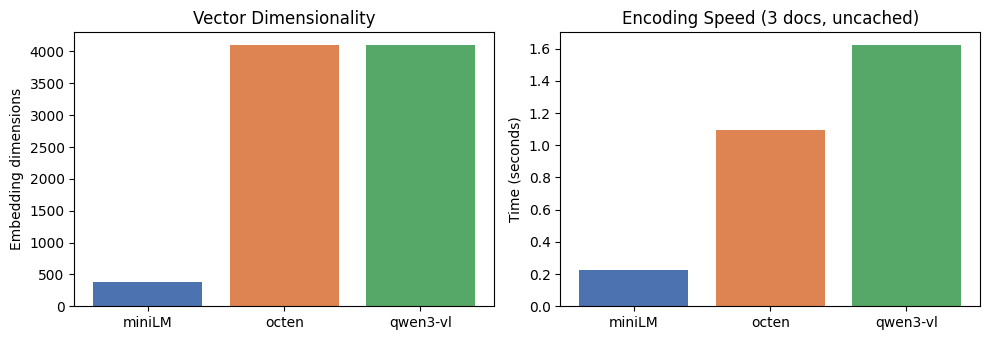

In [8]:
# ── 4: Speed benchmark + dimensionality analysis ──
doc_names = list(DOCUMENTS.keys())
doc_texts = list(DOCUMENTS.values())

TEXT_MODELS = {
    "miniLM":    embed_minilm,
    "octen":     embed_octen,
    "qwen3-vl":  lambda texts: embed_qwen3vl(texts=texts),
}

text_embeddings: dict[str, np.ndarray] = {}  # model_name → (n_docs, dim) array

print(f"Embedding {len(doc_texts)} documents...\n")
print(f"{'Model':20s}  {'Dim':>6s}  {'Time (s)':>9s}  {'Docs/s':>8s}  {'Memory (KB)':>11s}")
print("-" * 68)

# Cached full-corpus embeddings: skipped on second run unless RECREATE=True.
# We still measure speed on a fresh sample of 3 docs below for the bar chart.
for model_name, embed_fn in TEXT_MODELS.items():
    start = time.perf_counter()
    arr = cached_embed(
        f"docs_{model_name}_{len(doc_texts)}",
        lambda f=embed_fn: f(doc_texts),
    )
    elapsed = time.perf_counter() - start
    text_embeddings[model_name] = arr

    dim = arr.shape[1]
    mem_kb = arr.nbytes / 1024
    docs_per_sec = len(doc_texts) / elapsed if elapsed > 0 else float("inf")

    print(f"{model_name:20s}  {dim:>6d}  {elapsed:>9.3f}  {docs_per_sec:>8.1f}  {mem_kb:>11.1f}")

# Bar chart: speed comparison (always re-measure on 3 docs for a fair, cache-free timing)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

names = list(text_embeddings.keys())
dims = [text_embeddings[n].shape[1] for n in names]
times = []  # re-measure for the chart
for model_name, embed_fn in TEXT_MODELS.items():
    start = time.perf_counter()
    _ = embed_fn(doc_texts[:3])  # small sample for fair re-timing (not cached)
    times.append(time.perf_counter() - start)

ax1.bar(names, dims, color=["#4C72B0", "#DD8452", "#55A868"])
ax1.set_ylabel("Embedding dimensions")
ax1.set_title("Vector Dimensionality")

ax2.bar(names, times, color=["#4C72B0", "#DD8452", "#55A868"])
ax2.set_ylabel("Time (seconds)")
ax2.set_title("Encoding Speed (3 docs, uncached)")

plt.tight_layout()
plt.show()


---
## 5 · Image Embedding (dinov3-vit-large)

DINOv2 is a self-supervised vision model — it embeds images into a semantic space
without any text. We can use it to find **visually similar images**.

### 5.1 · Matryoshka truncation of `octen-embedding-8b`

`octen-embedding-8b` was trained with **Matryoshka Representation Learning (MRL)**: any prefix `v[:d]` of the full 4096-dim vector is itself a valid unit-norm embedding. Smaller prefixes lose fine-grained detail but keep the coarse semantics carried by the head dimensions.

We test this empirically by:

1. Embedding the same corpus (4000-char chunks of the HPI text) and the 100 sample queries from `queries.txt` at **full 4096 dims**.
2. Slicing both sides to widths $d \in \{4096, 2048, 1024, 512, 256, 128\}$, re-normalising to unit length.
3. Indexing each width into a separate Qdrant collection `nb_octen_mrl_{d}`.
4. Running the 100 queries against each collection and computing **Shannon entropy** of the top-K similarity scores.

**Expected reading.** Higher entropy = the retriever is less decisive (scores spread evenly across many chunks). If MRL works as advertised, entropy stays low for large prefixes and only degrades gracefully for very small widths (e.g. 128).


Built 38 chars_4000 chunks from 20 documents
Loaded 100 queries from queries.txt
  [cache hit ] mrl_corpus_octen_chars4000_4096.npy
  [cache hit ] mrl_queries_octen_4096.npy
Corpus matrix : (38, 4096)
Queries matrix: (100, 4096)
  [nb_octen_mrl_4096] indexed 38 chunks (dim=4096)
  [nb_octen_mrl_2048] indexed 38 chunks (dim=2048)
  [nb_octen_mrl_1024] indexed 38 chunks (dim=1024)
  [nb_octen_mrl_512] indexed 38 chunks (dim=512)
  [nb_octen_mrl_256] indexed 38 chunks (dim=256)
  [nb_octen_mrl_128] indexed 38 chunks (dim=128)

Done! Entropy values computed for every MRL width.


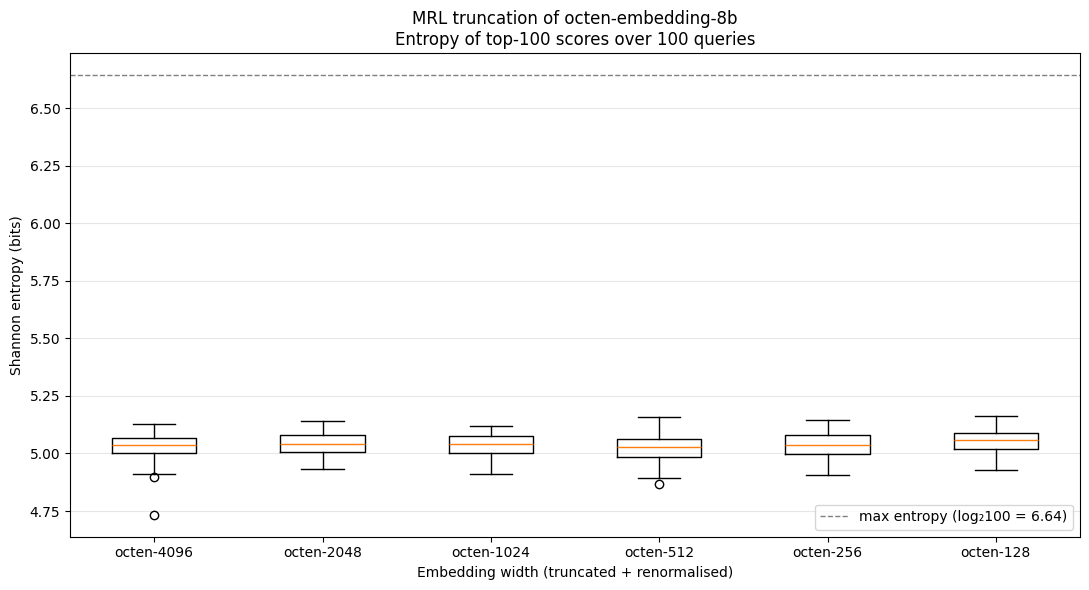


--- Summary statistics (entropy, bits) ---
Width              Mean      Std      Min      Max   Median
------------------------------------------------------------
octen-4096        5.031    0.055    4.734    5.129    5.035
octen-2048        5.038    0.049    4.932    5.141    5.042
octen-1024        5.037    0.049    4.910    5.121    5.040
octen-512         5.026    0.057    4.866    5.159    5.028
octen-256         5.035    0.057    4.907    5.145    5.039
octen-128         5.056    0.051    4.927    5.164    5.058


In [24]:
# ── 4.5: Matryoshka truncation experiment ──
import re

MRL_DIMS = [4096, 2048, 1024, 512, 256, 128]

# --- Replicate the chars_4000 chunking from w2_01 (4000-char windows, no overlap) ---
CHUNK_CHARS = 4000
mrl_chunks: list[str] = []
mrl_chunk_meta: list[dict] = []
for doc_name, text in DOCUMENTS.items():
    for offset in range(0, len(text), CHUNK_CHARS):
        chunk = text[offset:offset + CHUNK_CHARS].strip()
        if chunk:
            mrl_chunks.append(chunk)
            mrl_chunk_meta.append({"doc": doc_name, "offset": offset})
print(f"Built {len(mrl_chunks)} chars_4000 chunks from {len(DOCUMENTS)} documents")

# --- Load 100 sample queries from shared queries.txt ---
SAMPLE_QUERIES = [
    q.strip()
    for q in Path("queries.txt").read_text(encoding="utf-8").splitlines()
    if q.strip()
]
print(f"Loaded {len(SAMPLE_QUERIES)} queries from queries.txt")

TOP_K_MRL = len(SAMPLE_QUERIES)

# --- Embed corpus + queries once at 4096 dims (cached) ---
def _batch_embed_octen(texts, batch=16):
    out = []
    for i in range(0, len(texts), batch):
        out.extend(embed_octen(texts[i:i + batch]))
        if (i // batch) % 4 == 0:
            print(f"    embedded {min(i + batch, len(texts))} / {len(texts)}")
    return out

corpus_full = cached_embed(
    "mrl_corpus_octen_chars4000_4096",
    lambda: _batch_embed_octen(mrl_chunks),
)
queries_full = cached_embed(
    "mrl_queries_octen_4096",
    lambda: _batch_embed_octen(SAMPLE_QUERIES),
)
print(f"Corpus matrix : {corpus_full.shape}")
print(f"Queries matrix: {queries_full.shape}")


# --- Shannon entropy of top-K scores (duplicated from w2_01) ---
def entropy(scores, top_n=None):
    """Compute Shannon entropy (bits) of similarity scores normalised to probabilities."""
    if top_n is not None:
        scores = sorted(scores, reverse=True)[:top_n]
    arr = np.asarray(scores, dtype=float)
    # Shift to positive range (cosine can be slightly negative); softmax-ish normalisation
    arr = arr - arr.min() + 1e-9
    p = arr / arr.sum()
    return float(-np.sum(p * np.log2(p + 1e-12)))


def l2_normalise(matrix: np.ndarray) -> np.ndarray:
    """Row-wise L2 normalisation."""
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.clip(norms, 1e-12, None)


# --- Build one Qdrant collection per MRL width and run retrieval ---
entropy_per_width: dict[int, list[float]] = {d: [] for d in MRL_DIMS}

for d in MRL_DIMS:
    coll = f"nb_octen_mrl_{d}"

    # Truncate both sides to first d dims, then renormalise
    corpus_d = l2_normalise(corpus_full[:, :d])
    queries_d = l2_normalise(queries_full[:, :d])

    # (Re-)create collection at this width
    if qdrant.collection_exists(coll):
        qdrant.delete_collection(coll)
    qdrant.create_collection(
        collection_name=coll,
        vectors_config=models.VectorParams(size=d, distance=models.Distance.COSINE),
    )

    # Upsert corpus
    points = [
        models.PointStruct(
            id=i,
            vector=corpus_d[i].tolist(),
            payload={"doc": mrl_chunk_meta[i]["doc"], "offset": mrl_chunk_meta[i]["offset"], "width": d},
        )
        for i in range(len(corpus_d))
    ]
    # Batch upsert (avoid huge single request)
    for s in range(0, len(points), 256):
        qdrant.upsert(collection_name=coll, points=points[s:s + 256])
    print(f"  [{coll}] indexed {len(points)} chunks (dim={d})")

    # Query and collect entropy
    for q_idx in range(len(queries_d)):
        results = qdrant.query_points(
            collection_name=coll,
            query=queries_d[q_idx].tolist(),
            limit=TOP_K_MRL,
        ).points
        scores = [r.score for r in results]
        if scores:
            entropy_per_width[d].append(entropy(scores, top_n=TOP_K_MRL))

print("\nDone! Entropy values computed for every MRL width.")


# --- Boxplot ---
fig, ax = plt.subplots(figsize=(11, 6))
widths_sorted = sorted(MRL_DIMS, reverse=True)
data = [entropy_per_width[d] for d in widths_sorted]
labels = [f"octen-{d}" for d in widths_sorted]
ax.boxplot(data, tick_labels=labels)

max_ent = np.log2(TOP_K_MRL)
ax.axhline(max_ent, color="grey", linestyle="--", linewidth=1, label=f"max entropy (log₂{TOP_K_MRL} = {max_ent:.2f})")

ax.set_ylabel("Shannon entropy (bits)")
ax.set_xlabel("Embedding width (truncated + renormalised)")
ax.set_title(f"MRL truncation of octen-embedding-8b\nEntropy of top-{TOP_K_MRL} scores over {len(SAMPLE_QUERIES)} queries")
ax.legend(loc="lower right")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# --- Summary statistics ---
print("\n--- Summary statistics (entropy, bits) ---")
print(f"{'Width':<14} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8}")
print("-" * 60)
for d in widths_sorted:
    vals = entropy_per_width[d]
    if vals:
        print(f"octen-{d:<8} {np.mean(vals):>8.3f} {np.std(vals):>8.3f} {np.min(vals):>8.3f} {np.max(vals):>8.3f} {np.median(vals):>8.3f}")


**Reading the boxplot.** MRL-trained octen keeps retrieval entropy nearly flat from 4096 down to ~512 dims — proof that head dimensions carry the load.

**Practical takeaway.** If storage or latency is tight, truncating octen vectors is a free win.


Embedding 30 images with dinov3-vit-large...
  [cache hit ] images_dinov3_30.npy
  dim=1024, time=0.00s, shape=(30, 1024)


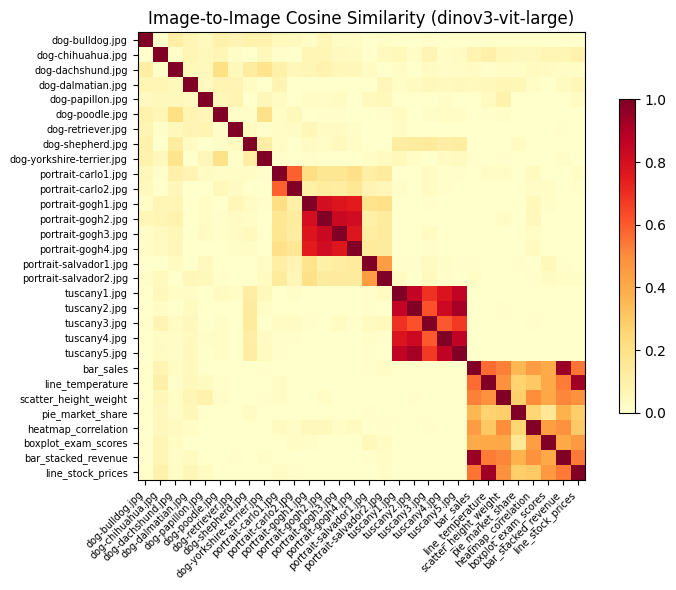

In [10]:
# ── 5a: Embed all images with dinov3 ──
print(f"Embedding {len(IMAGES)} images with dinov3-vit-large...")

start = time.perf_counter()
img_b64_list = [img["base64"] for img in IMAGES]
dinov3_arr = cached_embed(
    f"images_dinov3_{len(IMAGES)}",
    lambda: embed_dinov3(img_b64_list),
)
elapsed = time.perf_counter() - start

print(f"  dim={dinov3_arr.shape[1]}, time={elapsed:.2f}s, shape={dinov3_arr.shape}")

# Image-to-image similarity matrix
img_names = [img["name"] for img in IMAGES]
sim_img = cosine_similarity_matrix(dinov3_arr)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_img, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(img_names)))
ax.set_xticklabels(img_names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(img_names)))
ax.set_yticklabels(img_names, fontsize=7)
ax.set_title("Image-to-Image Cosine Similarity (dinov3-vit-large)")
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()


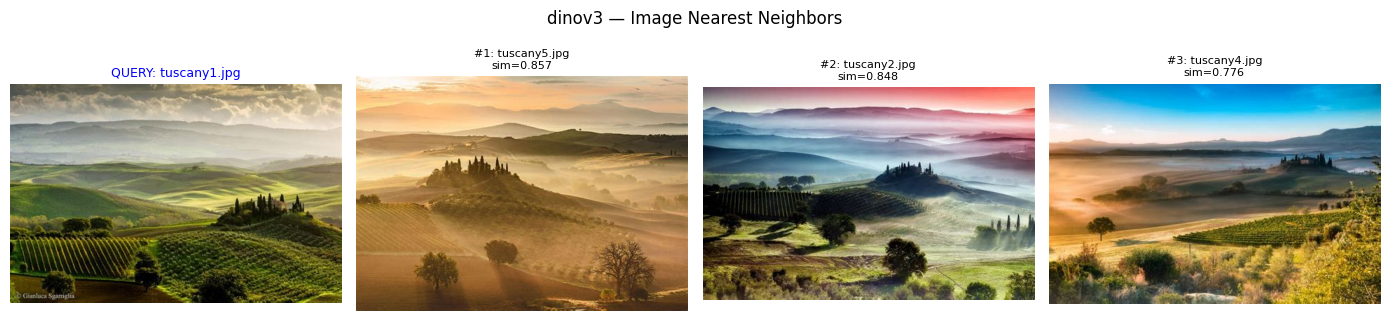

In [30]:
# ── 5b: Image nearest-neighbor retrieval ──
# Pick the first image as "query", show top-3 most similar
query_name = 'tuscany1.jpg'
#query_name = 'portrait-gogh1.jpg'
#query_name = 'dog-poodle.jpg'
#query_name = 'dog-shepherd.jpg'
query_idx = img_names.index(query_name)
similarities = sim_img[query_idx].copy()
similarities[query_idx] = -1  # exclude self

top3 = np.argsort(similarities)[-3:][::-1]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
# Query image
query_img = Image.open(io.BytesIO(base64.b64decode(IMAGES[query_idx]["base64"])))
axes[0].imshow(query_img)
axes[0].set_title(f"QUERY: {query_name}", fontsize=9, color="blue")
axes[0].axis("off")

for ax_idx, img_idx in enumerate(top3, 1):
    img = Image.open(io.BytesIO(base64.b64decode(IMAGES[img_idx]["base64"])))
    axes[ax_idx].imshow(img)
    axes[ax_idx].set_title(f"#{ax_idx}: {img_names[img_idx]}\nsim={similarities[img_idx]:.3f}", fontsize=8)
    axes[ax_idx].axis("off")

plt.suptitle("dinov3 — Image Nearest Neighbors", fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
# ── 5c: Can we use a TEXT query with dinov3? ──
# dinov3 is a pure vision model (DINOv2 family) — let's see what happens
# when we try to send it a text query instead of an image.

text_query = "Monthly sales chart"
print(f"Attempting to embed text with dinov3: '{text_query}'\n")

try:
    resp = http_requests.post(
        f"{BASE_URL}/embeddings",
        json={"input": [text_query], "model": "dinov3-vit-large"},
        headers={
            "Authorization": f"Bearer {API_KEY}",
            "Content-Type": "application/json",
        },
        timeout=30,
    )
    if not resp.ok:
        print(f"Error {resp.status_code}:")
        print(resp.text[:500])
    else:
        print("Unexpected success — embedding returned:")
        print(resp.json()["data"][0]["embedding"][:5])
except Exception as exc:
    print(f"Exception: {exc}")

Attempting to embed text with dinov3: 'Monthly sales chart'

Error 500:
{"error":{"message":"litellm.APIConnectionError: Text-only input is not supported. Provide image URLs or image objects.\nTraceback (most recent call last):\n  File \"/usr/lib/python3.13/site-packages/litellm/main.py\", line 5774, in embedding\n    response = base_llm_http_handler.embedding(\n        model=model,\n    ...<10 lines>...\n        litellm_params={\"ssl_verify\": kwargs.get(\"ssl_verify\", None)},\n    )\n  File \"/usr/lib/python3.13/site-packages/litellm/llms/custom_httpx/llm_http_ha


**Why did this fail?**

`dinov3-vit-large` is based on **DINOv2** — a self-supervised **vision-only** model.
It has **no text encoder at all**; its input pipeline expects raw pixel data (i.e. images).
When we send plain text, the model cannot process it and returns an error.

**Consequence for retrieval:** With dinov3 we can only do **image → image** search.
If we want to search images using a **text query** (or vice versa), we need a model
that maps both modalities into the same embedding space — that's exactly what
**qwen3-vl-embedding-8b** does. We'll explore this in section 6.

---
## 6 · Multimodal Embedding (qwen3-vl-embedding-8b)

Qwen3-VL can embed both **text** and **images** into the **same vector space**.
This enables cross-modal retrieval: text query → find relevant images, and vice versa.

  [cache hit ] images_qwen3vl_512_30.npy

  Embedded 30/30 images
  dim=4096, time=0.00s, shape=(30, 4096)

Text embeddings (qwen3-vl):  shape=(20, 4096)
Image embeddings (qwen3-vl): shape=(30, 4096)

Both share the SAME 4096-dimensional vector space!
This means we can compute cosine similarity between ANY text and ANY image.


/tmp/ipykernel_173635/3350048382.py:90: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_173635/3350048382.py:90: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/hanmul/Workshops/workshop-ragV2/notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hanmul/Workshops/workshop-ragV2/notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


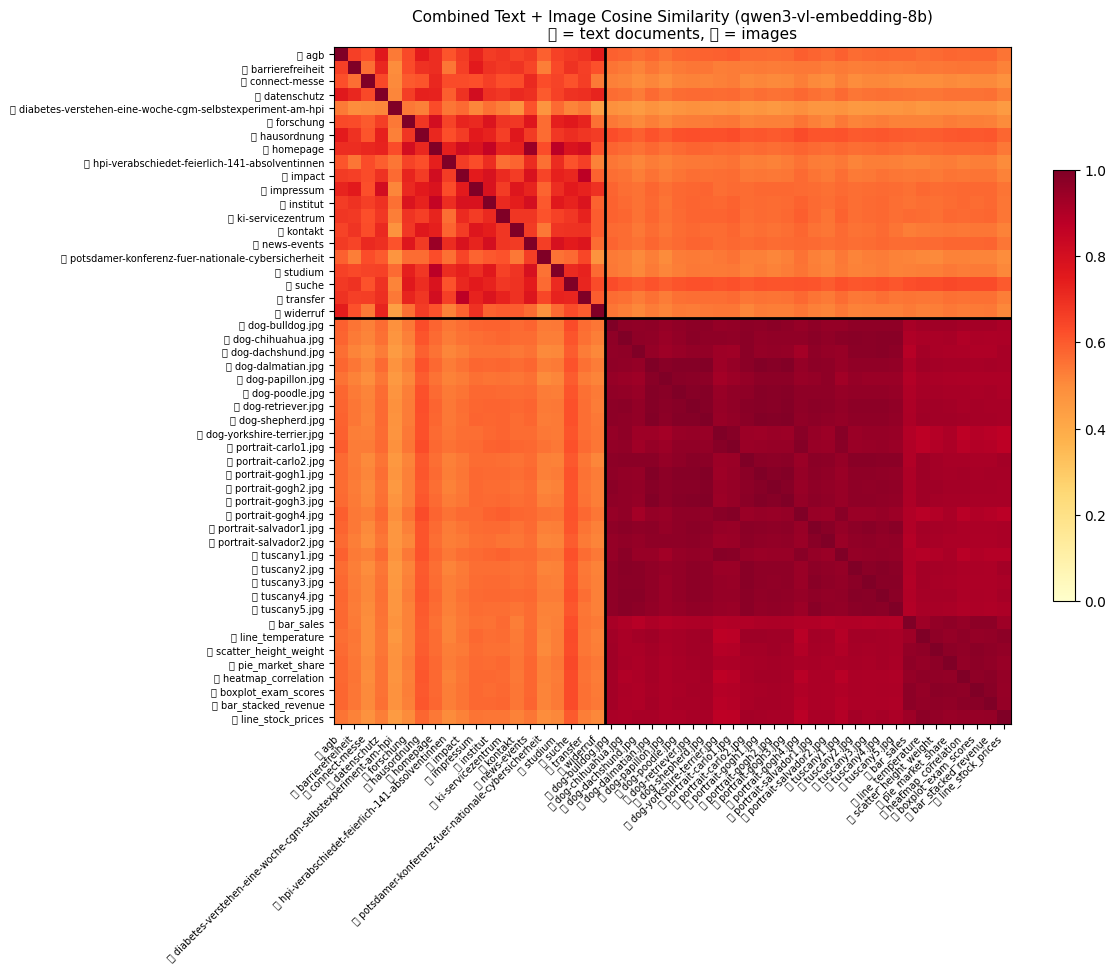

In [32]:
# ── 6a: Embed all images with qwen3-vl ──
# Some images may exceed the 32K-token context window even at 768px.
# We use a smaller max size here and retry with progressively smaller
# resolutions if the API still rejects an image.

def embed_images_qwen3vl_safe(images: list[dict], max_pixels: int = 512) -> tuple[list[np.ndarray], list[int]]:
    """Embed images with qwen3-vl, retrying with smaller sizes on context-window errors.
    Returns (list_of_vectors, list_of_successful_indices).
    """
    vecs, ok_indices = [], []
    for idx, img_dict in enumerate(images):
        b64 = img_dict["base64"]
        embedded = False
        for px in [max_pixels, max_pixels // 2, max_pixels // 4]:
            try:
                resized = _resize_image_b64(b64, max_side=px)
                data_uri = _to_data_uri(resized)
                resp = _retry(
                    client.embeddings.create,
                    input=[data_uri], model="qwen3-vl-embedding-8b", encoding_format="float",
                    label=f"qwen3-vl img {idx+1}/{len(images)} ({px}px)",
                )
                vecs.append(np.array(resp.data[0].embedding))
                ok_indices.append(idx)
                embedded = True
                break
            except Exception as exc:
                if "ContextWindow" in str(exc) or "context length" in str(exc):
                    print(f"  ⚠ {img_dict['name']}: too large at {px}px, retrying smaller...")
                    continue
                raise
        if not embedded:
            print(f"  ✗ Skipped {img_dict['name']} — still exceeds context window at {max_pixels // 4}px")
    return vecs, ok_indices


# Cache both the vector matrix and the successful-index list.
_qwen3vl_vec_path = CACHE_DIR / f"images_qwen3vl_512_{len(IMAGES)}.npy"
_qwen3vl_idx_path = CACHE_DIR / f"images_qwen3vl_512_{len(IMAGES)}_idx.npy"

if _qwen3vl_vec_path.exists() and _qwen3vl_idx_path.exists() and not RECREATE:
    print(f"  [cache hit ] {_qwen3vl_vec_path.name}")
    qwen3vl_img_arr = np.load(_qwen3vl_vec_path)
    qwen3vl_img_ok = np.load(_qwen3vl_idx_path).tolist()
    elapsed = 0.0
else:
    print(f"  [cache miss] {_qwen3vl_vec_path.name} — computing ...")
    print(f"Embedding {len(IMAGES)} images with qwen3-vl-embedding-8b (max 512px)...")
    start = time.perf_counter()
    qwen3vl_img_vecs, qwen3vl_img_ok = embed_images_qwen3vl_safe(IMAGES, max_pixels=512)
    qwen3vl_img_arr = np.stack(qwen3vl_img_vecs)
    elapsed = time.perf_counter() - start
    np.save(_qwen3vl_vec_path, qwen3vl_img_arr)
    np.save(_qwen3vl_idx_path, np.array(qwen3vl_img_ok))

qwen3vl_img_names = [img_names[i] for i in qwen3vl_img_ok]
print(f"\n  Embedded {len(qwen3vl_img_arr)}/{len(IMAGES)} images")
print(f"  dim={qwen3vl_img_arr.shape[1]}, time={elapsed:.2f}s, shape={qwen3vl_img_arr.shape}")

# ── 6b: Combined text + image similarity matrix ──
# Reuse text embeddings from section 4
qwen3vl_text_arr = text_embeddings["qwen3-vl"]

print(f"\nText embeddings (qwen3-vl):  shape={qwen3vl_text_arr.shape}")
print(f"Image embeddings (qwen3-vl): shape={qwen3vl_img_arr.shape}")
print(f"\nBoth share the SAME {qwen3vl_text_arr.shape[1]}-dimensional vector space!")
print("This means we can compute cosine similarity between ANY text and ANY image.")

# Stack text and image embeddings into one matrix
combined_embeddings = np.vstack([qwen3vl_text_arr, qwen3vl_img_arr])
combined_labels = [f"📄 {n}" for n in doc_names] + [f"🖼 {n}" for n in qwen3vl_img_names]

# Compute full similarity matrix (text-text, text-image, image-image)
sim_combined = cosine_similarity_matrix(combined_embeddings)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_combined, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(combined_labels)))
ax.set_xticklabels(combined_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(combined_labels)))
ax.set_yticklabels(combined_labels, fontsize=7)

# Add separator lines between text and image blocks
n_text = len(doc_names)
ax.axhline(y=n_text - 0.5, color="black", linewidth=2)
ax.axvline(x=n_text - 0.5, color="black", linewidth=2)

ax.set_title("Combined Text + Image Cosine Similarity (qwen3-vl-embedding-8b)\n📄 = text documents, 🖼 = images", fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()


Text query: 'Monthly sales chart'

Top-3 images for text query:
  #1: bar_sales                       sim=0.5428
  #2: pie_market_share                sim=0.5396
  #3: scatter_height_weight           sim=0.5367

Image query: 'pie_market_share'

Top-3 documents for image query:
  #1: suche                           sim=0.6394
  #2: hausordnung                     sim=0.6040
  #3: agb                             sim=0.5776


/tmp/ipykernel_173635/701437237.py:75: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


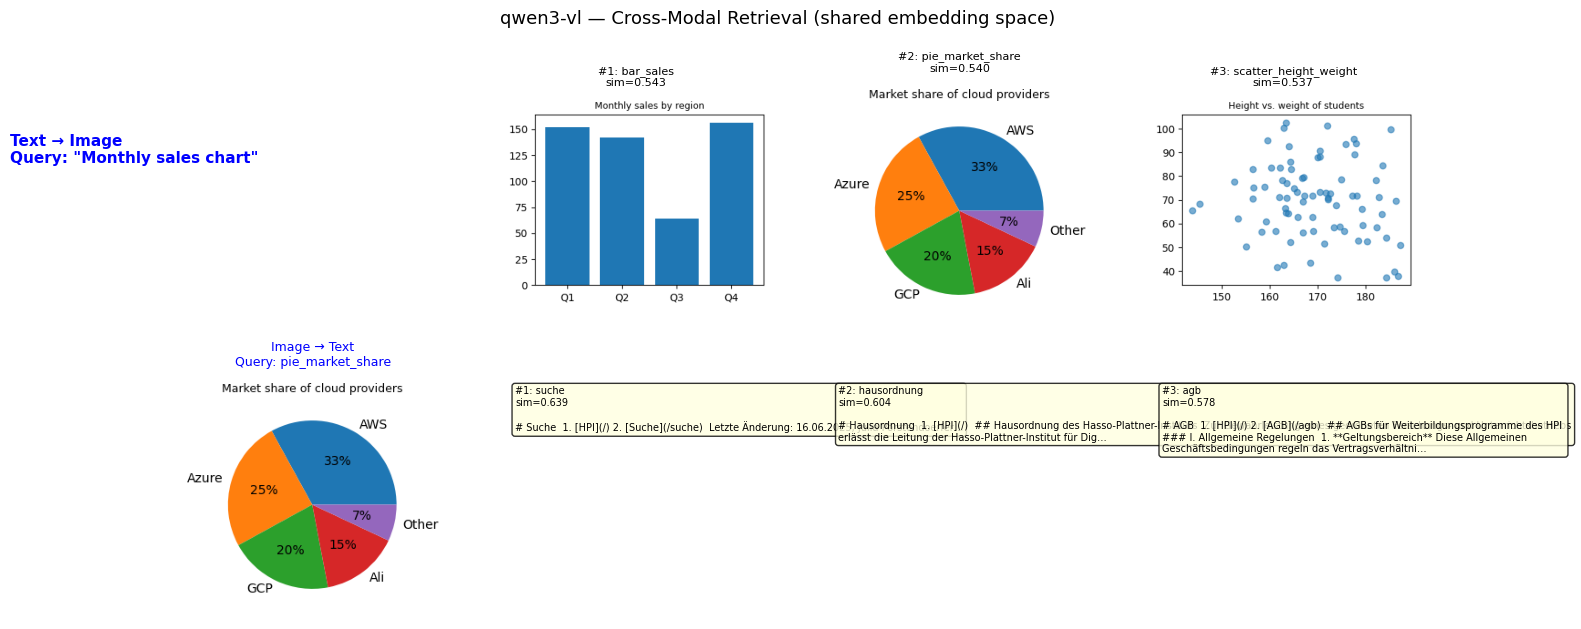

In [33]:
# ── 6c: Cross-modal retrieval demo ──
# Unlike dinov3, qwen3-vl lets us search ACROSS modalities:
#   1. Text query  → find relevant images
#   2. Image query → find relevant text documents

# ── 1. Text → Image retrieval ──
text_query = "Monthly sales chart"
print(f"Text query: '{text_query}'")

q_vec_text = embed_qwen3vl(texts=[text_query])[0]
text2img_scores = [cosine_sim(q_vec_text, qwen3vl_img_arr[i]) for i in range(len(qwen3vl_img_names))]
top3_img_idx = np.argsort(text2img_scores)[-3:][::-1]

print(f"\nTop-3 images for text query:")
for rank, idx in enumerate(top3_img_idx, 1):
    print(f"  #{rank}: {qwen3vl_img_names[idx]:30s}  sim={text2img_scores[idx]:.4f}")

# ── 2. Image → Text retrieval ──
# Use the synthetic "pie_market_share" chart as the image query.
# This chart depicts cloud-provider market share (AWS, Azure, GCP, ...),
# which should surface text documents about IT / cloud / business topics.
QUERY_IMG_NAME = "pie_market_share"
query_local_idx = next(
    (i for i, n in enumerate(qwen3vl_img_names) if n.startswith(QUERY_IMG_NAME)),
    None,
)
if query_local_idx is None:
    raise ValueError(
        f"Image '{QUERY_IMG_NAME}' was not embedded successfully — "
        f"check the qwen3vl_img_names list."
    )

query_orig_idx = qwen3vl_img_ok[query_local_idx]
query_img_name = qwen3vl_img_names[query_local_idx]
print(f"\nImage query: '{query_img_name}'")

q_vec_img = qwen3vl_img_arr[query_local_idx]
img2text_scores = [cosine_sim(q_vec_img, qwen3vl_text_arr[i]) for i in range(len(doc_names))]
top3_doc_idx = np.argsort(img2text_scores)[-3:][::-1]

print(f"\nTop-3 documents for image query:")
for rank, idx in enumerate(top3_doc_idx, 1):
    print(f"  #{rank}: {doc_names[idx]:30s}  sim={img2text_scores[idx]:.4f}")

# ── Visualisation ──
fig = plt.figure(figsize=(16, 7))

# Row 1: Text → Image
fig.text(0.02, 0.78, f"Text → Image\nQuery: \"{text_query}\"", fontsize=11,
         fontweight="bold", va="center", color="blue")
for rank, idx in enumerate(top3_img_idx):
    ax = fig.add_subplot(2, 4, rank + 2)
    orig_idx = qwen3vl_img_ok[idx]
    img = Image.open(io.BytesIO(base64.b64decode(IMAGES[orig_idx]["base64"])))
    ax.imshow(img)
    ax.set_title(f"#{rank+1}: {qwen3vl_img_names[idx]}\nsim={text2img_scores[idx]:.3f}", fontsize=8)
    ax.axis("off")

# Row 2: Image → Text
ax_query = fig.add_subplot(2, 4, 5)
query_pil = Image.open(io.BytesIO(base64.b64decode(IMAGES[query_orig_idx]["base64"])))
ax_query.imshow(query_pil)
ax_query.set_title(f"Image → Text\nQuery: {query_img_name}", fontsize=9, color="blue")
ax_query.axis("off")

for rank, idx in enumerate(top3_doc_idx):
    ax = fig.add_subplot(2, 4, rank + 6)
    snippet = doc_texts[idx][:200].replace("\n", " ")
    ax.text(0.05, 0.95, f"#{rank+1}: {doc_names[idx]}\nsim={img2text_scores[idx]:.3f}\n\n{snippet}…",
            transform=ax.transAxes, fontsize=7, va="top", wrap=True,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    ax.axis("off")

plt.suptitle("qwen3-vl — Cross-Modal Retrieval (shared embedding space)", fontsize=13)
plt.tight_layout()
plt.show()


### Evaluation Queries

To measure retrieval quality we define labelled queries where each query has a set
of **relevant document names** (matching keys in `DOCUMENTS`).
These will be used in section 7 to compute MRR and nDCG@5.

In [34]:
# ── Evaluation queries with relevance labels ──
# A small labeled subset for the MRR / nDCG@5 evaluation below.
# The 100 shared queries (notebooks/queries.txt) are loaded separately in the MRL section
# above for the entropy experiment.

LABELED_EVAL_QUERIES = [
    {
        "query": "Welche Studiengänge bietet das HPI an?",
        "relevant": ["studium"],
    },
    {
        "query": "Welche Forschungsschwerpunkte hat das HPI?",
        "relevant": ["forschung", "institut"],
    },
    {
        "query": "Wie kann ich das KI-Servicezentrum kontaktieren?",
        "relevant": ["ki-servicezentrum"],
    },
    {
        "query": "Welche Veranstaltungen und Neuigkeiten gibt es?",
        "relevant": ["news-events"],
    },
    {
        "query": "Datenschutz und Impressum des HPI",
        "relevant": ["datenschutz", "impressum"],
    },
]

# Back-compat alias for downstream cells
EVAL_QUERIES = LABELED_EVAL_QUERIES

print(f"Defined {len(LABELED_EVAL_QUERIES)} labeled evaluation queries:")
for j, eq in enumerate(LABELED_EVAL_QUERIES, 1):
    print(f"  {j}. \"{eq['query']}\"  →  relevant: {eq['relevant']}")


Defined 5 labeled evaluation queries:
  1. "Welche Studiengänge bietet das HPI an?"  →  relevant: ['studium']
  2. "Welche Forschungsschwerpunkte hat das HPI?"  →  relevant: ['forschung', 'institut']
  3. "Wie kann ich das KI-Servicezentrum kontaktieren?"  →  relevant: ['ki-servicezentrum']
  4. "Welche Veranstaltungen und Neuigkeiten gibt es?"  →  relevant: ['news-events']
  5. "Datenschutz und Impressum des HPI"  →  relevant: ['datenschutz', 'impressum']


---
## 7 · Consolidated Comparison

### 7.1 — Retrieval quality metrics (MRR & nDCG@5)

Using the evaluation queries defined above, we compute:
- **MRR** (Mean Reciprocal Rank): How high does the first relevant result appear?
- **nDCG@5** (Normalised Discounted Cumulative Gain): Overall ranking quality in the top-5.

          Model       MRR    nDCG@5
------------------------------------
         miniLM    0.6848    0.6613
          octen    1.0000    0.9226
       qwen3-vl    1.0000    0.9754


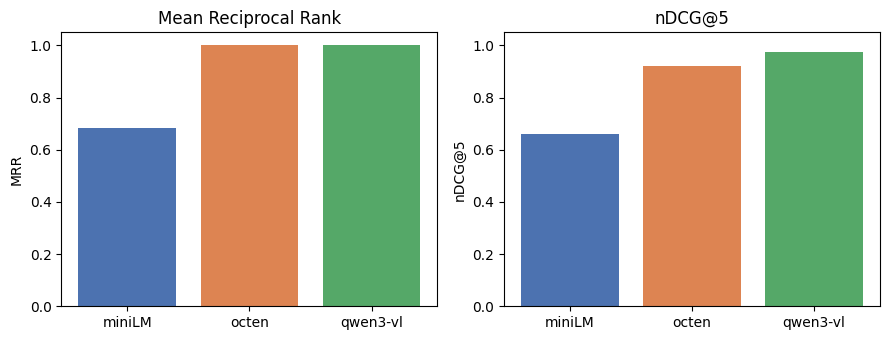

In [35]:
# ── 7.1: MRR and nDCG@5 ──

def reciprocal_rank(ranked_docs: list[str], relevant: set[str]) -> float:
    """Return 1/rank of the first relevant doc, or 0 if none found."""
    for rank, doc in enumerate(ranked_docs, 1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked_docs: list[str], relevant: set[str], k: int = 5) -> float:
    """Normalised Discounted Cumulative Gain at k."""
    dcg = 0.0
    for i, doc in enumerate(ranked_docs[:k]):
        if doc in relevant:
            dcg += 1.0 / np.log2(i + 2)  # i+2 because rank starts at 1
    # Ideal DCG: all relevant docs at top
    ideal = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / ideal if ideal > 0 else 0.0


metrics = {m: {"mrr": [], "ndcg": []} for m in TEXT_MODELS}

for eq in EVAL_QUERIES:
    query = eq["query"]
    relevant = set(eq["relevant"])

    for model_name, embed_fn in TEXT_MODELS.items():
        q_vec = embed_fn([query])[0]
        doc_arr = text_embeddings[model_name]
        scores = [cosine_sim(q_vec, doc_arr[i]) for i in range(len(doc_names))]
        ranked = [doc_names[i] for i in np.argsort(scores)[::-1]]

        metrics[model_name]["mrr"].append(reciprocal_rank(ranked, relevant))
        metrics[model_name]["ndcg"].append(ndcg_at_k(ranked, relevant, k=5))

# Summary table
print(f"{'Model':>15s}  {'MRR':>8s}  {'nDCG@5':>8s}")
print("-" * 36)
for model_name in TEXT_MODELS:
    mrr = np.mean(metrics[model_name]["mrr"])
    ndcg = np.mean(metrics[model_name]["ndcg"])
    print(f"{model_name:>15s}  {mrr:>8.4f}  {ndcg:>8.4f}")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
names = list(TEXT_MODELS.keys())
colors = ["#4C72B0", "#DD8452", "#55A868"]

ax1.bar(names, [np.mean(metrics[n]["mrr"]) for n in names], color=colors)
ax1.set_ylabel("MRR")
ax1.set_title("Mean Reciprocal Rank")
ax1.set_ylim(0, 1.05)

ax2.bar(names, [np.mean(metrics[n]["ndcg"]) for n in names], color=colors)
ax2.set_ylabel("nDCG@5")
ax2.set_title("nDCG@5")
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### 7.2 — Similarity distribution

How do models "spread" their cosine similarity scores?
A model that clusters everything near 0.9 makes it hard to distinguish relevant from
irrelevant documents. Wider distributions are generally better for retrieval.

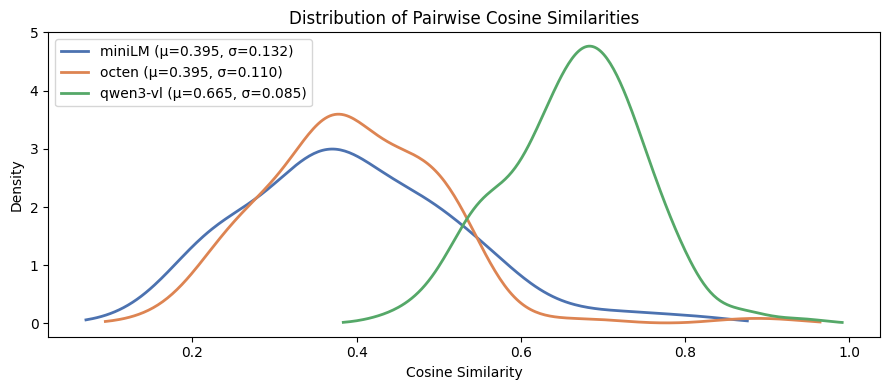

In [36]:
# ── 7.2: Similarity distribution (KDE) ──
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 4))
colors = {"miniLM": "#4C72B0", "octen": "#DD8452", "qwen3-vl": "#55A868"}

for model_name, arr in text_embeddings.items():
    sim = cosine_similarity_matrix(arr)
    # Extract upper triangle (exclude diagonal)
    upper = sim[np.triu_indices_from(sim, k=1)]

    kde = gaussian_kde(upper)
    x_grid = np.linspace(upper.min() - 0.05, upper.max() + 0.05, 300)
    ax.plot(x_grid, kde(x_grid), label=f"{model_name} (μ={upper.mean():.3f}, σ={upper.std():.3f})",
            color=colors.get(model_name, None), linewidth=2)

ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Density")
ax.set_title("Distribution of Pairwise Cosine Similarities")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Exercises

### Exercise 1 — Embed PDFs with qwen3-vl

The `raw_data/` folder contains PDFs (e.g. `lstm.pdf`, `curioussingapore.pdf`).
Use qwen3-vl to embed them as images (base64-encoded pages) and compare
against text-only embedding of the same PDFs extracted via Docling.

In [18]:
# TODO: Exercise 1
# Hints:
# 1. Use Docling to extract text from a PDF:
#      from docling.document_converter import DocumentConverter
#      converter = DocumentConverter()
#      result = converter.convert("raw_data/lstm.pdf")
#      pdf_text = result.document.export_to_markdown()
#
# 2. Convert PDF pages to images (e.g. using pdf2image or fitz/PyMuPDF)
# 3. Embed the text with embed_octen / embed_qwen3vl
# 4. Embed the page images with embed_qwen3vl(images_b64=...)
# 5. Compare: does text-based or image-based embedding find more relevant results?

### Exercise 2 — Distance metrics

Qdrant supports `COSINE`, `DOT`, and `EUCLID` distance metrics.
Create three collections (same model, different metrics) and compare retrieval
results. Which metric works best for which model?

In [19]:
# TODO: Exercise 2
# Hints:
# 1. Pick one model (e.g. miniLM) and its embeddings from text_embeddings
# 2. Create 3 Qdrant collections:
#      models.Distance.COSINE, models.Distance.DOT, models.Distance.EUCLID
# 3. Upsert the same embeddings into all 3
# 4. Run the same queries against all 3 and compare ranking + scores

### Exercise 3 — Mini multimodal search engine

Build a small search engine that, given a **text query**, retrieves both:
- The most relevant **text chunks** (via miniLM or octen)
- The most relevant **images** (via qwen3-vl)

Display the results side by side.

In [20]:
# TODO: Exercise 3
# Hints:
# 1. Store image embeddings (qwen3-vl) in a Qdrant collection
# 2. For a query, embed it with both a text model and qwen3-vl
# 3. Search the text collection for relevant chunks
# 4. Search the image collection for relevant images
# 5. Display text results + image results side by side using matplotlib

---
## 9 · Cleanup

Delete the Qdrant collections created by this notebook.

In [21]:
# Uncomment to delete all collections created by this notebook:
# NB02_COLLECTIONS = ["nb02_miniLM", "nb02_octen", "nb02_qwen3_vl"]
# NB02_COLLECTIONS += [f"nb_octen_mrl_{d}" for d in [4096, 2048, 1024, 512, 256, 128]]
# for col_name in NB02_COLLECTIONS:
#     if qdrant.collection_exists(col_name):
#         qdrant.delete_collection(col_name)
#         print(f"Deleted collection '{col_name}'")
